<a href="https://colab.research.google.com/github/tanveer135/diabetes-prediction-preprocessing-analysis/blob/main/02_Diabetes_Prediction_Model_Development_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Prediction Using Machine Learning
## Model Development and Evaluation Pipeline
#### ------------------------------------------------
### This script performs:
1. Data loading
2. Data preprocessing and feature engineering
3. Handling class imbalance using SMOTE
4. Model training (Random Forest, Logistic Regression, Gradient Boosting)
5. Model evaluation using Confusion Matrix, Classification Report, and ROC-AUC

In [ ]:
# =========================
# All Required Imports
# =========================

# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train/Test split
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Load the data

In [ ]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Dissertation/diabetes_dataset_with_notes.csv")

# View first rows
df.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


# Data cleaning and pre-processing

## Remove Unwanted Features

In [ ]:
# Drop unnecessary columns
df = df.drop(columns=[
    'clinical_notes',
    'location',
    'race:AfricanAmerican',
    'race:Asian',
    'race:Caucasian',
    'race:Hispanic',
    'race:Other'
])

df.columns

Index(['year', 'gender', 'age', 'hypertension', 'heart_disease',
       'smoking_history', 'bmi', 'hbA1c_level', 'blood_glucose_level',
       'diabetes'],
      dtype='object')

## Separate Features and Target

In [ ]:
# Separate features and target
X = df.drop('diabetes', axis=1)
y = df['diabetes']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (100000, 9)
Target shape: (100000,)


## Encode Categorical Variables

In [ ]:
# Encode categorical variables
X = pd.get_dummies(X, columns=['gender', 'smoking_history'], drop_first=True)

X.head()

,year,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,2020,32.0,0,0,27.32,5.0,100,False,False,False,False,False,True,False
1,2015,29.0,0,0,19.95,5.0,90,False,False,False,False,False,True,False
2,2015,18.0,0,0,23.76,4.8,160,True,False,False,False,False,True,False
3,2015,41.0,0,0,27.32,4.0,159,True,False,False,False,False,True,False
4,2016,52.0,0,0,23.75,6.5,90,False,False,False,False,False,True,False


In [ ]:
# Convert only boolean columns to integers
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

X.head()

,year,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,2020,32.0,0,0,27.32,5.0,100,0,0,0,0,0,1,0
1,2015,29.0,0,0,19.95,5.0,90,0,0,0,0,0,1,0
2,2015,18.0,0,0,23.76,4.8,160,1,0,0,0,0,1,0
3,2015,41.0,0,0,27.32,4.0,159,1,0,0,0,0,1,0
4,2016,52.0,0,0,23.75,6.5,90,0,0,0,0,0,1,0


## Outlier Handling (BMI Capping)

From EDA:

BMI had extreme values (up to ~95).


We will cap outliers using IQR method.

In [ ]:
# Calculate IQR for BMI
Q1 = X['bmi'].quantile(0.25)
Q3 = X['bmi'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: 14.705
Upper bound: 38.504999999999995


### Cap BMI Outliers

Those bounds make medical sense.

So:
- Lower bound ≈ 14.7

-- Upper bound ≈ 38.5

That means:
- BMI < 14.7 → extremely underweight (likely unrealistic here)
- BMI > 38.5 → extreme obesity (many values above this are probably synthetic or noisy)

In [ ]:
# Cap BMI values
X['bmi'] = X['bmi'].clip(lower=lower_bound, upper=upper_bound)

# Check new min and max
print("New BMI min:", X['bmi'].min())
print("New BMI max:", X['bmi'].max())

New BMI min: 14.705
New BMI max: 38.504999999999995


# Train/Test Split (Stratified)

Because dataset is imbalanced (8.5% positive),
we MUST use stratification.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Training set size: (80000, 14)
Test set size: (20000, 14)

Train class distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64

Test class distribution:
diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


## Models

## Train Random Forest (Balanced Version)

Because the data is imbalanced, we use: `class_weight="balanced"`

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### Make Predictions

In [ ]:
# Predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("Predictions generated.")

Predictions generated.


### Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("\nROC-AUC Score:", roc_auc)

Confusion Matrix:
 [[18234    66]
 [  534  1166]]

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.95      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000


ROC-AUC Score: 0.963384699453552


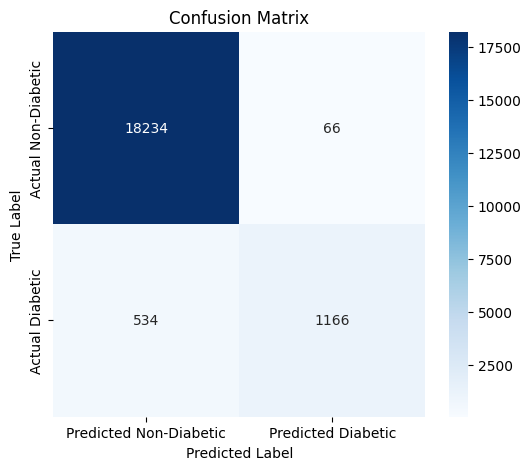

In [ ]:
c

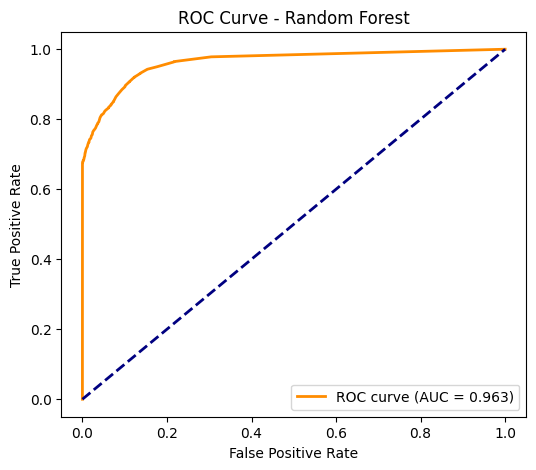

In [ ]:
c

# Feature Importance

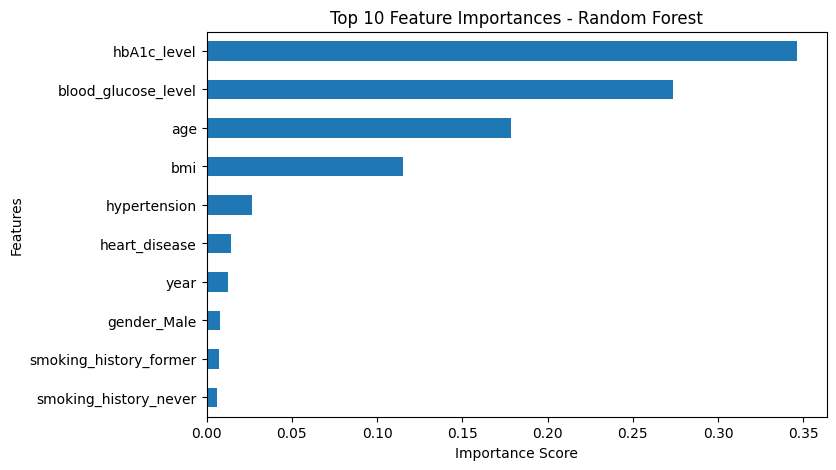

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Create feature importance series
feature_importances = pd.Series(rf.feature_importances_, index=X.columns)

# Sort values
feature_importances = feature_importances.sort_values(ascending=False)

# Select top 10
top_features = feature_importances.head(10)

# Plot
plt.figure(figsize=(8,5))
top_features.sort_values().plot(kind='barh')

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [ ]:
import pandas as pd

feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

feature_importances.head(10)

,0
hbA1c_level,0.346255
blood_glucose_level,0.273368
age,0.178741
bmi,0.115150
hypertension,0.026733
heart_disease,0.014372
year,0.012789
gender_Male,0.008068
smoking_history_former,0.007379
smoking_history_never,0.006312


## Train Random Forest (Unbalanced)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest WITHOUT class weighting
rf_unbalanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_unbalanced.fit(X_train, y_train)

print("Unbalanced model trained successfully.")

Unbalanced model trained successfully.


### Predictions

In [ ]:
# Predictions from unbalanced model
y_pred_unbalanced = rf_unbalanced.predict(X_test)
y_proba_unbalanced = rf_unbalanced.predict_proba(X_test)[:, 1]

### Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Confusion Matrix
cm_unbalanced = confusion_matrix(y_test, y_pred_unbalanced)
print("Confusion Matrix (Unbalanced):\n", cm_unbalanced)

# Classification Report
print("\nClassification Report (Unbalanced):\n")
print(classification_report(y_test, y_pred_unbalanced))

# ROC-AUC
roc_auc_unbalanced = roc_auc_score(y_test, y_proba_unbalanced)
print("\nROC-AUC Score (Unbalanced):", roc_auc_unbalanced)

Confusion Matrix (Unbalanced):
 [[18248    52]
 [  535  1165]]

Classification Report (Unbalanced):

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.96      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000


ROC-AUC Score (Unbalanced): 0.9619670202507232


The comparison between balanced and unbalanced Random Forest models showed negligible performance differences. This suggests that the strong predictive signal within key metabolic features reduces the impact of class imbalance on model performance.

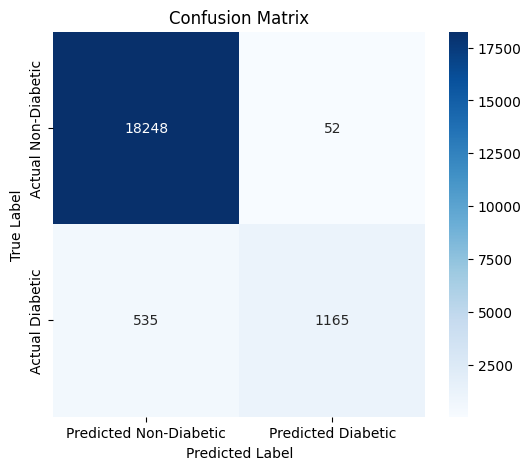

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_unbalanced)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Non-Diabetic", "Predicted Diabetic"],
            yticklabels=["Actual Non-Diabetic", "Actual Diabetic"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

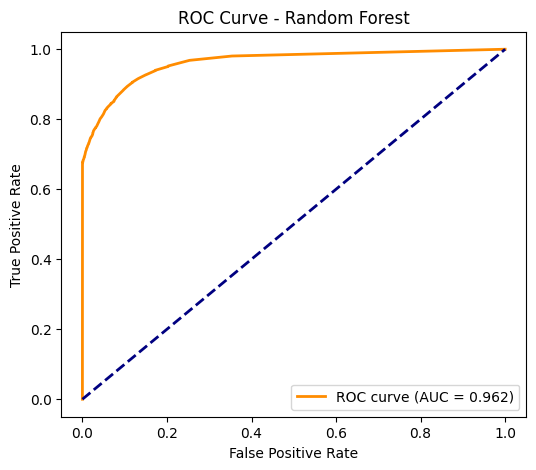

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_proba_unbalanced)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()

# SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_balanced.value_counts())

Before SMOTE: diabetes
0    73200
1     6800
Name: count, dtype: int64
After SMOTE: diabetes
1    73200
0    73200
Name: count, dtype: int64


## Random Forest + SMOTE

In [ ]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(X_train_balanced, y_train_balanced)

RandomForestClassifier(random_state=42)

### Prediction

In [ ]:
y_pred_smote = rf_smote.predict(X_test)
y_proba_smote = rf_smote.predict_proba(X_test)[:,1]

### Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
print("Confusion Matrix (SMOTE):\n", cm_smote)

# Classification Report
print("\nClassification Report (SMOTE):\n")
print(classification_report(y_test, y_pred_smote))

# ROC-AUC
roc_auc_smote = roc_auc_score(y_test, y_proba_smote)
print("\nROC-AUC Score (SMOTE):", roc_auc_smote)

Confusion Matrix (SMOTE):
 [[17925   375]
 [  464  1236]]

Classification Report (SMOTE):

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     18300
           1       0.77      0.73      0.75      1700

    accuracy                           0.96     20000
   macro avg       0.87      0.85      0.86     20000
weighted avg       0.96      0.96      0.96     20000


ROC-AUC Score (SMOTE): 0.9612609771777563


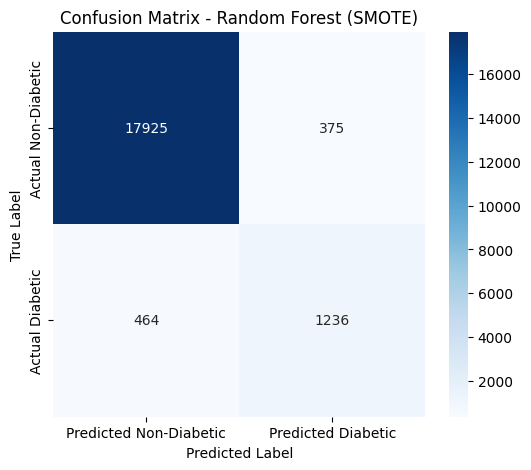

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm_smote, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Non-Diabetic", "Predicted Diabetic"],
            yticklabels=["Actual Non-Diabetic", "Actual Diabetic"])

plt.title("Confusion Matrix - Random Forest (SMOTE)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

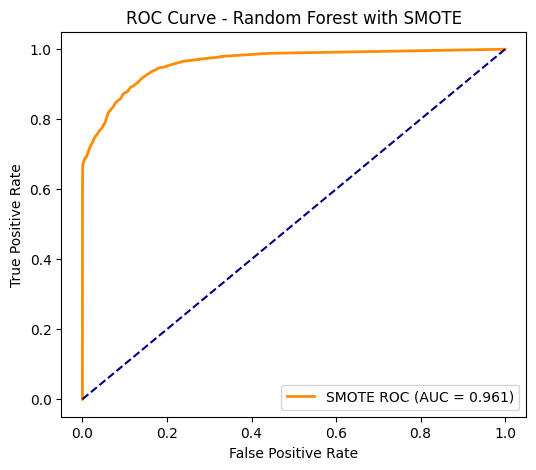

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_smote, tpr_smote, _ = roc_curve(y_test, y_proba_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

plt.figure(figsize=(6,5))
plt.plot(fpr_smote, tpr_smote, color='darkorange',
         lw=2, label=f'SMOTE ROC (AUC = {roc_auc_smote:.3f})')
plt.plot([0,1],[0,1],'--', color='navy')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest with SMOTE")
plt.legend()
plt.show()

## Logistic REeression + SMOTE

In [ ]:
# =========================
# Logistic Regression Model
# =========================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create pipeline (scaling + logistic regression)
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=5000))
])

log_model.fit(X_train_balanced, y_train_balanced)

print("Logistic Regression model trained successfully.")

# =========================
# Predictions
# =========================

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:,1]

# =========================
# Evaluation
# =========================

cm_log = confusion_matrix(y_test, y_pred_log)

print("Confusion Matrix (Logistic Regression):\n", cm_log)

print("\nClassification Report (Logistic Regression):\n")
print(classification_report(y_test, y_pred_log))

roc_auc_log = roc_auc_score(y_test, y_proba_log)
print("\nROC-AUC Score (Logistic Regression):", roc_auc_log)

Logistic Regression model trained successfully.
Confusion Matrix (Logistic Regression):
 [[16487  1813]
 [  358  1342]]

Classification Report (Logistic Regression):

              precision    recall  f1-score   support

           0       0.98      0.90      0.94     18300
           1       0.43      0.79      0.55      1700

    accuracy                           0.89     20000
   macro avg       0.70      0.85      0.75     20000
weighted avg       0.93      0.89      0.91     20000


ROC-AUC Score (Logistic Regression): 0.9433007714561235


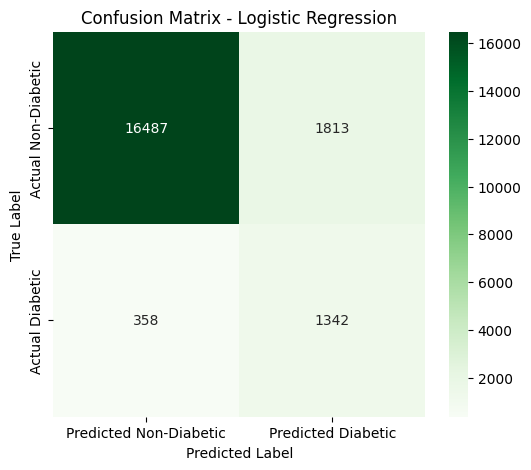

In [ ]:
# =========================
# Confusion Matrix Graph
# =========================

plt.figure(figsize=(6,5))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Predicted Non-Diabetic", "Predicted Diabetic"],
            yticklabels=["Actual Non-Diabetic", "Actual Diabetic"])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

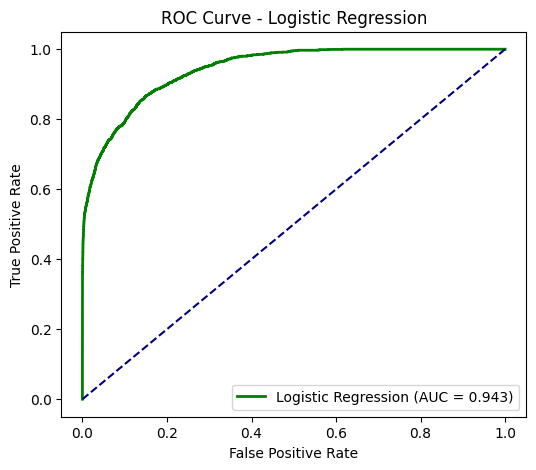

In [ ]:
# =========================
# ROC Curve
# =========================

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)

plt.figure(figsize=(6,5))
plt.plot(fpr_log, tpr_log, color='green', lw=2,
         label=f'Logistic Regression (AUC = {roc_auc_log:.3f})')
plt.plot([0,1],[0,1],'--', color='navy')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

# Gradient Boosting + SMOTE

In [ ]:
# =========================
# Gradient Boosting Model
# =========================

# Import required libraries
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Create Gradient Boosting model
# n_estimators = number of trees used in boosting
# learning_rate = step size used to update model weights
# random_state = ensures reproducibility of results
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train the model using SMOTE balanced training data
# X_train_balanced and y_train_balanced contain oversampled data
gb_model.fit(X_train_balanced, y_train_balanced)

# Confirmation message after training
print("Gradient Boosting model trained successfully.")

# =========================
# Predictions
# =========================

# Predict class labels (0 = Non-Diabetic, 1 = Diabetic)
y_pred_gb = gb_model.predict(X_test)

# Predict probability scores for ROC-AUC calculation
# [:,1] selects probability of the positive class (Diabetic)
y_proba_gb = gb_model.predict_proba(X_test)[:,1]

# =========================
# Evaluation
# =========================

# Generate confusion matrix to evaluate prediction results
cm_gb = confusion_matrix(y_test, y_pred_gb)

# Print confusion matrix
print("Confusion Matrix (Gradient Boosting):\n", cm_gb)

# Print classification report
# Includes Precision, Recall, F1-score, and Support
print("\nClassification Report (Gradient Boosting):\n")
print(classification_report(y_test, y_pred_gb))

# Calculate ROC-AUC score to measure model discrimination ability
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)

# Print ROC-AUC score
print("\nROC-AUC Score (Gradient Boosting):", roc_auc_gb)

Gradient Boosting model trained successfully.
Confusion Matrix (Gradient Boosting):
 [[17865   435]
 [  438  1262]]

Classification Report (Gradient Boosting):

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     18300
           1       0.74      0.74      0.74      1700

    accuracy                           0.96     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.96      0.96      0.96     20000


ROC-AUC Score (Gradient Boosting): 0.969970668595307


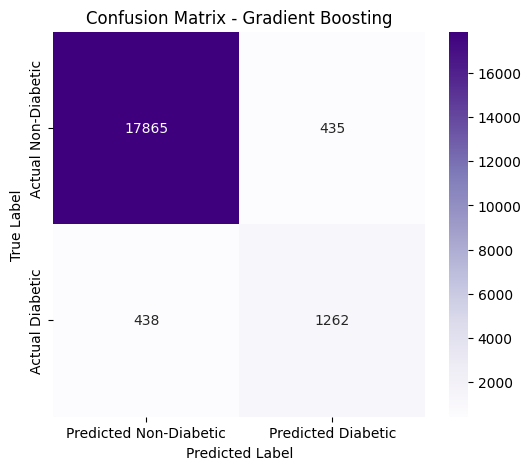

In [ ]:
# =========================
# Confusion Matrix Graph
# =========================

# Create a new figure for the confusion matrix visualization
plt.figure(figsize=(6,5))

# Plot the confusion matrix as a heatmap
# cm_gb contains the confusion matrix values for the Gradient Boosting model
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Purples",
            # Labels for predicted classes on X-axis
            xticklabels=["Predicted Non-Diabetic", "Predicted Diabetic"],
            # Labels for actual classes on Y-axis
            yticklabels=["Actual Non-Diabetic", "Actual Diabetic"])

# Title of the confusion matrix plot
plt.title("Confusion Matrix - Gradient Boosting")

# Label for X-axis (model predictions)
plt.xlabel("Predicted Label")

# Label for Y-axis (true/actual values)
plt.ylabel("True Label")

# Display the confusion matrix heatmap
plt.show()

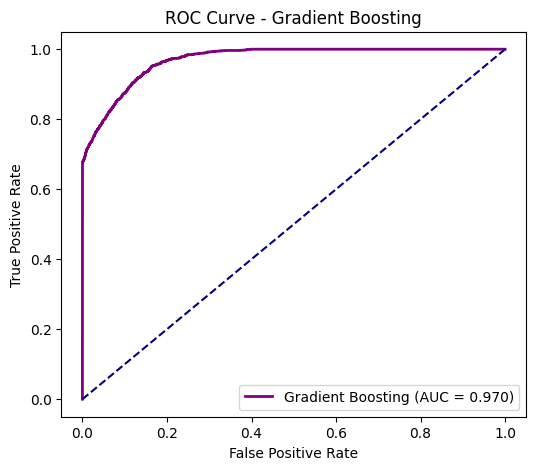

In [ ]:
# =========================
# ROC Curve
# =========================

# Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
# using the predicted probabilities of the Gradient Boosting model
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

# Create a new figure for the ROC plot
plt.figure(figsize=(6,5))

# Plot the ROC curve for the Gradient Boosting model
# It shows how well the model separates the positive and negative classes
plt.plot(fpr_gb, tpr_gb, color='purple', lw=2,
         label=f'Gradient Boosting (AUC = {roc_auc_gb:.3f})')

# Plot a diagonal reference line (random classifier baseline)
# A model performing better than random will have a curve above this line
plt.plot([0,1],[0,1],'--', color='navy')

# Label for X-axis
plt.xlabel("False Positive Rate")

# Label for Y-axis
plt.ylabel("True Positive Rate")

# Title of the plot
plt.title("ROC Curve - Gradient Boosting")

# Show legend containing model name and AUC score
plt.legend()

# Display the ROC curve
plt.show()

Among the evaluated models, Gradient Boosting achieved the highest ROC-AUC score (0.970), indicating superior discriminative ability. While Random Forest achieved slightly higher overall accuracy (0.97), Gradient Boosting demonstrated a more balanced trade-off between precision and recall. Logistic Regression achieved the highest recall but suffered from low precision, leading to a high number of false positive predictions.